# 🌲 XGBoost Classification — Breast Cancer Dataset

In [2]:
# Install dependencies (run once)
# !pip install xgboost scikit-learn pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# Display settings
pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")
print(f"   XGBoost version : {xgb.__version__}")
print(f"   NumPy   version : {np.__version__}")
print(f"   Pandas  version : {pd.__version__}")


✅ All libraries imported successfully!
   XGBoost version : 3.2.0
   NumPy   version : 2.3.5
   Pandas  version : 2.3.3


In [3]:
data   = load_breast_cancer()
X      = pd.DataFrame(data.data, columns=data.feature_names)
y      = pd.Series(data.target, name="target")

print("📦 Dataset: Breast Cancer Wisconsin")
print(f"   Samples  : {X.shape[0]}")
print(f"   Features : {X.shape[1]}")
print(f"   Classes  : {list(data.target_names)}")
print()

📦 Dataset: Breast Cancer Wisconsin
   Samples  : 569
   Features : 30
   Classes  : [np.str_('malignant'), np.str_('benign')]



In [4]:
# Class distribution
counts = y.value_counts().rename(index={1: "Benign (1)", 0: "Malignant (0)"})
print("🔢 Class Distribution:")
print(counts.to_string())


🔢 Class Distribution:
target
Benign (1)       357
Malignant (0)    212


In [5]:
# First 5 rows
X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# Statistical summary
X.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.13,3.52,6.98,11.70,13.37,15.78,28.11
mean texture,569.0,19.29,4.30,9.71,16.17,18.84,21.80,39.28
mean perimeter,569.0,91.97,24.30,43.79,75.17,86.24,104.10,188.50
mean area,569.0,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
mean smoothness,569.0,0.10,0.01,0.05,0.09,0.10,0.11,0.16
mean compactness,569.0,0.10,0.05,0.02,0.06,0.09,0.13,0.35
mean concavity,569.0,0.09,0.08,0.00,0.03,0.06,0.13,0.43
mean concave points,569.0,0.05,0.04,0.00,0.02,0.03,0.07,0.20
mean symmetry,569.0,0.18,0.03,0.11,0.16,0.18,0.20,0.30
mean fractal dimension,569.0,0.06,0.01,0.05,0.06,0.06,0.07,0.10


❓ Missing values: 0


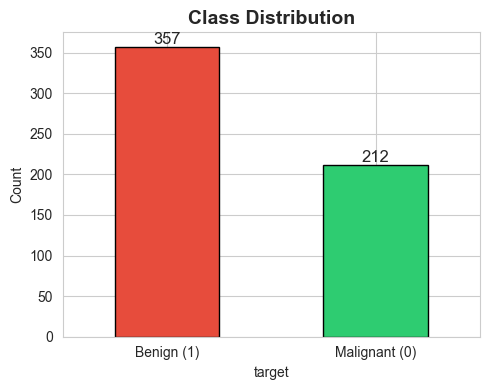

In [7]:
# Check for missing values
missing = X.isnull().sum().sum()
print(f"❓ Missing values: {missing}")

# Class distribution bar chart
fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind="bar", color=["#e74c3c", "#2ecc71"], edgecolor="black", ax=ax)
ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
ax.set_xticklabels(counts.index, rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", fontsize=12)
plt.tight_layout()
plt.show()


In [8]:
# Train / Test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✂️  Data Split Summary:")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing  samples : {X_test.shape[0]}")
print()
print("📊 Training class distribution:")
print(y_train.value_counts().to_string())
print()
print("📊 Testing class distribution:")
print(y_test.value_counts().to_string())


✂️  Data Split Summary:
   Training samples : 455
   Testing  samples : 114

📊 Training class distribution:
target
1    285
0    170

📊 Testing class distribution:
target
1    72
0    42


In [9]:
# Convert to XGBoost DMatrix format (optimised memory & speed)
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(X.columns))
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=list(X.columns))
print("✅ DMatrix objects created successfully!")


✅ DMatrix objects created successfully!


In [10]:
# Define hyperparameters
params = {
    "objective"       : "binary:logistic",  # binary classification
    "eval_metric"     : "logloss",          # evaluation metric
    "max_depth"       : 4,                  # tree depth
    "learning_rate"   : 0.1,               # eta / step size
    "subsample"       : 0.8,               # row sampling per tree
    "colsample_bytree": 0.8,               # feature sampling per tree
    "reg_alpha"       : 0.1,               # L1 regularisation
    "reg_lambda"      : 1.0,               # L2 regularisation
    "seed"            : 42,
}

print("⚙️  Model Parameters:")
for k, v in params.items():
    print(f"   {k:<20}: {v}")


⚙️  Model Parameters:
   objective           : binary:logistic
   eval_metric         : logloss
   max_depth           : 4
   learning_rate       : 0.1
   subsample           : 0.8
   colsample_bytree    : 0.8
   reg_alpha           : 0.1
   reg_lambda          : 1.0
   seed                : 42


In [11]:
# Train model with early stopping
evals        = [(dtrain, "train"), (dtest, "eval")]
evals_result = {}

model = xgb.train(
    params,
    dtrain,
    num_boost_round       = 200,
    evals                 = evals,
    early_stopping_rounds = 15,
    evals_result          = evals_result,
    verbose_eval          = 20,          # print every 20 rounds
)

print(f"\n✅ Training complete!")
print(f"   Best iteration : {model.best_iteration}")
print(f"   Best logloss   : {model.best_score:.5f}")


[0]	train-logloss:0.57808	eval-logloss:0.58007
[20]	train-logloss:0.10553	eval-logloss:0.14865
[40]	train-logloss:0.04027	eval-logloss:0.09728
[60]	train-logloss:0.02337	eval-logloss:0.08510
[80]	train-logloss:0.01655	eval-logloss:0.08336
[89]	train-logloss:0.01466	eval-logloss:0.08473

✅ Training complete!
   Best iteration : 74
   Best logloss   : 0.08251


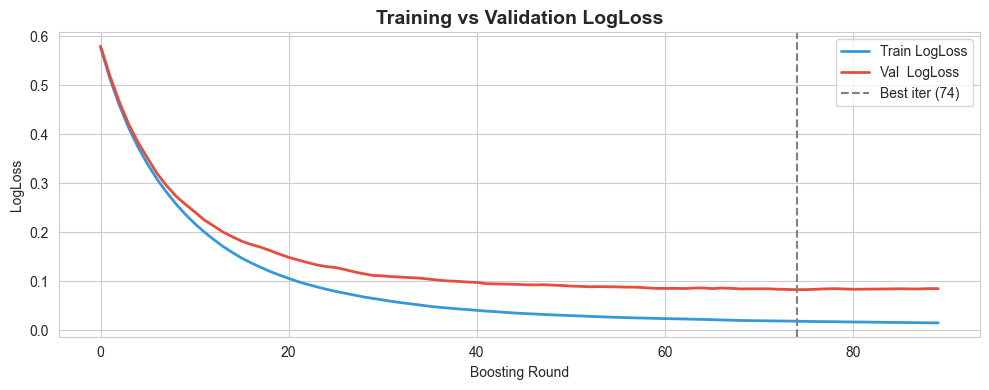

In [12]:
# Plot training vs validation loss
train_loss = evals_result["train"]["logloss"]
val_loss   = evals_result["eval"]["logloss"]

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label="Train LogLoss", color="#3498db", linewidth=2)
plt.plot(val_loss,   label="Val  LogLoss", color="#e74c3c", linewidth=2)
plt.axvline(model.best_iteration, color="gray", linestyle="--", label=f"Best iter ({model.best_iteration})")
plt.title("Training vs Validation LogLoss", fontsize=14, fontweight="bold")
plt.xlabel("Boosting Round")
plt.ylabel("LogLoss")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
# Predictions
y_prob = model.predict(dtest)                   # probabilities
y_pred = (y_prob > 0.5).astype(int)             # binary labels

# Core metrics
acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

print("📈 Evaluation Metrics:")
print(f"   Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"   ROC-AUC   : {auc:.4f}")
print()
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


📈 Evaluation Metrics:
   Accuracy  : 0.9474  (94.74%)
   ROC-AUC   : 0.9947

📋 Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.90      0.93        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



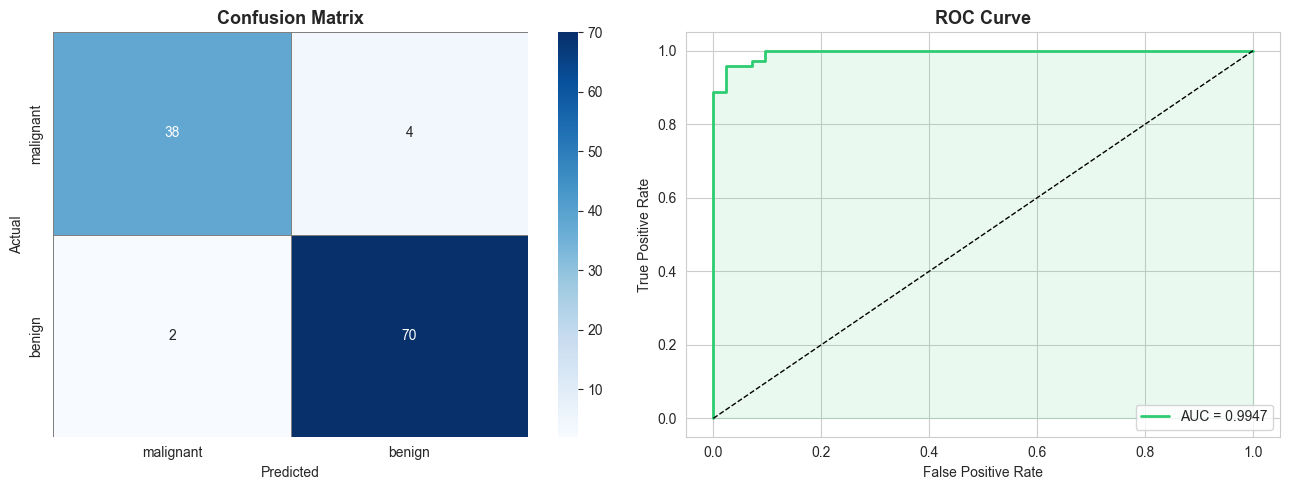

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Confusion Matrix --
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names,
            yticklabels=data.target_names, ax=axes[0],
            linewidths=0.5, linecolor="gray")
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# -- ROC Curve --
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#2ecc71", linewidth=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0,1],[0,1], "k--", linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#2ecc71")
axes[1].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


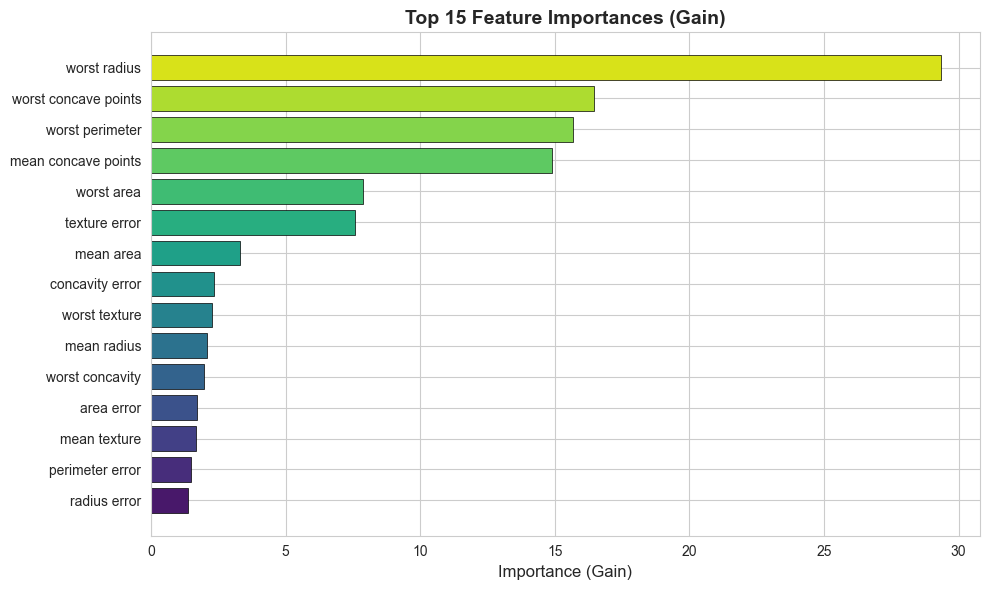


🏆 Top 5 Most Important Features:
   worst radius                       : 29.33
   worst concave points               : 16.44
   worst perimeter                    : 15.68
   mean concave points                : 14.90
   worst area                         : 7.89


In [15]:
# Feature importance scores
importance_dict = model.get_score(importance_type="gain")
feat_df = (
    pd.DataFrame(importance_dict.items(), columns=["Feature", "Importance"])
    .sort_values("Importance", ascending=False)
    .head(15)
)

# Plot
plt.figure(figsize=(10, 6))
colors = sns.color_palette("viridis", len(feat_df))
bars = plt.barh(feat_df["Feature"], feat_df["Importance"],
                color=colors[::-1], edgecolor="black", linewidth=0.5)
plt.xlabel("Importance (Gain)", fontsize=12)
plt.title("Top 15 Feature Importances (Gain)", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 Most Important Features:")
for i, row in feat_df.head(5).iterrows():
    print(f"   {row['Feature']:<35}: {row['Importance']:.2f}")


In [16]:
# Save model
model.save_model("xgboost_breast_cancer.json")
print("💾 Model saved as: xgboost_breast_cancer.json")

# Load model
loaded_model = xgb.Booster()
loaded_model.load_model("xgboost_breast_cancer.json")
print("📂 Model loaded successfully!")

# Verify loaded model gives same predictions
y_prob_loaded = loaded_model.predict(dtest)
y_pred_loaded = (y_prob_loaded > 0.5).astype(int)
acc_loaded    = accuracy_score(y_test, y_pred_loaded)
print(f"\n✅ Loaded model accuracy: {acc_loaded:.4f}")
print(f"   Predictions match: {np.allclose(y_prob, y_prob_loaded)}")


💾 Model saved as: xgboost_breast_cancer.json
📂 Model loaded successfully!

✅ Loaded model accuracy: 0.9474
   Predictions match: True
